# DSCI235 Final Project

https://github.com/Therasdin/DSCI235-Final.git

### Introduction

For this project, I analyzed a Spotify dataset containing various audio features of songs along with their popularity scores. The goal of this analysis is to explore how different musical characteristics, such as energy, danceability, tempo, and valence, relate to a song’s popularity. By examining these relationships, I aim to identify patterns that may help explain why certain songs are more popular than others.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
highPopularity = pd.read_csv("archive/high_popularity_spotify_data.csv")
lowPopularity = pd.read_csv("archive/low_popularity_spotify_data.csv")

highPopularity.head()


,energy,tempo,danceability,playlist_genre,loudness,liveness,valence,track_artist,time_signature,speechiness,...,instrumentalness,track_album_id,mode,key,duration_ms,acousticness,id,playlist_subgenre,type,playlist_id
0,0.592,157.969,0.521,pop,-7.777,0.122,0.535,"Lady Gaga, Bruno Mars",3,0.0304,...,0.0000,10FLjwfpbxLmW8c25Xyc2N,0,6,251668,0.3080,2plbrEY59IikOBgBGLjaoe,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M
1,0.507,104.978,0.747,pop,-10.171,0.117,0.438,Billie Eilish,4,0.0358,...,0.0608,7aJuG4TFXa2hmE4z1yxc3n,1,2,210373,0.2000,6dOtVTDdiauQNBQEDOtlAB,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M
2,0.808,108.548,0.554,pop,-4.169,0.159,0.372,Gracie Abrams,4,0.0368,...,0.0000,0hBRqPYPXhr1RkTDG3n4Mk,1,1,166300,0.2140,7ne4VBA60CxGM75vw0EYad,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M
3,0.910,112.966,0.670,pop,-4.070,0.304,0.786,Sabrina Carpenter,4,0.0634,...,0.0000,4B4Elma4nNDUyl6D5PvQkj,0,0,157280,0.0939,1d7Ptw3qYcfpdLNL5REhtJ,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M
4,0.783,149.027,0.777,pop,-4.477,0.355,0.939,"ROSÉ, Bruno Mars",4,0.2600,...,0.0000,2IYQwwgxgOIn7t3iF6ufFD,0,0,169917,0.0283,5vNRhkKd0yEAg8suGBpjeY,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M


In [3]:
highPopularity.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1686 entries, 0 to 1685
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   energy                    1686 non-null   float64
 1   tempo                     1686 non-null   float64
 2   danceability              1686 non-null   float64
 3   playlist_genre            1686 non-null   object 
 4   loudness                  1686 non-null   float64
 5   liveness                  1686 non-null   float64
 6   valence                   1686 non-null   float64
 7   track_artist              1686 non-null   object 
 8   time_signature            1686 non-null   int64  
 9   speechiness               1686 non-null   float64
 10  track_popularity          1686 non-null   int64  
 11  track_href                1686 non-null   object 
 12  uri                       1686 non-null   object 
 13  track_album_name          1685 non-null   object 
 14  playlist

One of the first things I noticed was that the dataset contains a mix of continuous numerical features (such as energy, tempo, and loudness) and categorical or descriptive variables (such as artist name and playlist genre). The numerical features are mostly normalized or fall within expected ranges, making them suitable for comparison and analysis.

I also observed that some variables are encoded numerically but represent categorical information. For example, the “key” feature is represented as an integer from 0 to 11, corresponding to musical pitch classes (e.g., 0 = C, 1 = C♯, up to 11 = B), rather than being labeled directly. Similarly, the “mode” variable indicates whether a track is in a major or minor key. This means that some preprocessing or interpretation may be needed when analyzing these features.

In [4]:
print(highPopularity["track_popularity"].mean())
print(highPopularity["track_popularity"].std())

print(lowPopularity["track_popularity"].mean())
print(lowPopularity["track_popularity"].std())
features = [
    'energy', 'danceability', 'loudness', 'tempo',
    'valence', 'speechiness', 'instrumentalness',
    'liveness', 'acousticness', 'duration_ms'
]

comparison = pd.DataFrame({
    'High Mean': highPopularity[features].mean(),
    'Low Mean': lowPopularity[features].mean(),
    'High Std': highPopularity[features].std(),
    'Low Std': lowPopularity[features].std()
})

comparison['Difference'] = comparison['High Mean'] - comparison['Low Mean']

print(comparison.sort_values(by='Difference', ascending=False))

75.80604982206405
6.03253189985256
43.479173290938
14.821766430847045
                      High Mean       Low Mean      High Std       Low Std  \
duration_ms       214562.125741  201640.174300  58310.747929  91573.903523   
tempo                121.070938     116.766884     27.066029     29.152400   
loudness              -6.704131     -10.663833      3.377068      8.155066   
energy                 0.667216       0.543509      0.184908      0.263635   
valence                0.525737       0.458438      0.236113      0.266140   
danceability           0.650362       0.607268      0.157721      0.200372   
liveness               0.171579       0.165487      0.123953      0.124652   
speechiness            0.100926       0.102174      0.099748      0.101726   
acousticness           0.221220       0.405567      0.250593      0.342249   
instrumentalness       0.041520       0.286603      0.156556      0.395181   

                    Difference  
duration_ms       12921.951441  
tempo

The data is split up into high and low popularity datasets. The High popularity dataset seems to have a lower distribution of songs. I first examined the distribution of popularity scores within the high and low popularity datasets by comparing their mean and standard deviation. The high popularity dataset had an average score of approximately 75.8 with a relatively small standard deviation of about 6.0, indicating that these songs are consistently rated within a narrow range of high popularity. In contrast, the low popularity dataset had a much lower average score of 43.5 and a significantly larger standard deviation of 14.8, showing that these songs vary widely in their popularity. This suggests that highly popular songs tend to follow a more consistent pattern, while less popular songs are more varied and less predictable in how they are received.

I then compared the mean and standard deviation of key audio features between the high and low popularity datasets. Several clear differences emerged. High popularity songs tend to have higher loudness, energy, tempo, valence, and danceability, suggesting that they are generally louder, more energetic, more positive in mood, and more suitable for dancing. These traits point toward a more engaging and mainstream sound. Additionally, popular songs were slightly longer in duration on average.

On the other hand, low popularity songs showed much higher values for instrumentalness and acousticness, indicating that songs with fewer vocals or more acoustic qualities are less likely to achieve high popularity. Features such as liveness and speechiness showed little to no difference between the two groups, suggesting that they do not play a major role in determining popularity. Overall, this comparison highlights that popular songs tend to be more energetic and produced, while less popular songs tend to be more instrumental or acoustic.

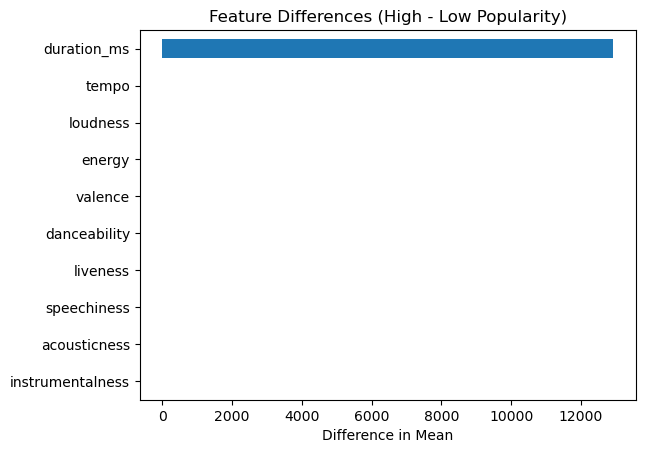

In [5]:
comparison['Difference'].sort_values().plot(kind='barh')
plt.title("Feature Differences (High - Low Popularity)")
plt.xlabel("Difference in Mean")
plt.show()

The horizontal bar chart above displays the difference in mean feature values between high and low popularity songs (High minus Low). Bars extending to the right indicate features that are higher on average in popular songs, while bars extending to the left indicate features more common in less popular songs. Instrumentalness and acousticness stand out as the most negative, while duration, tempo, and loudness show the largest positive differences.

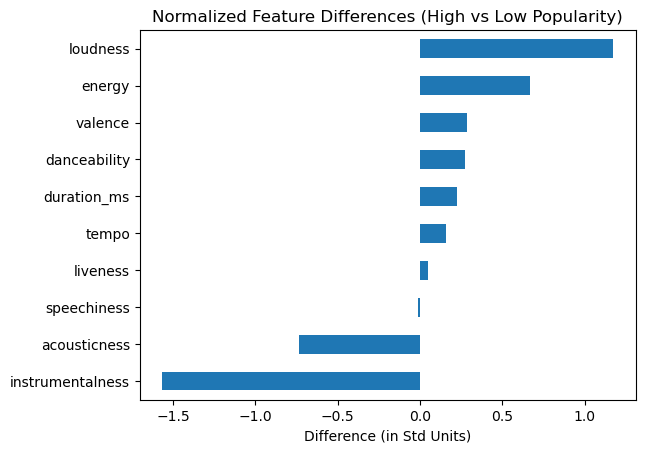

In [6]:
# Normalize differences so duration doesn’t dominate
normalized_diff = (comparison['Difference'] / comparison['High Std'])

normalized_diff.sort_values().plot(kind='barh')
plt.title("Normalized Feature Differences (High vs Low Popularity)")
plt.xlabel("Difference (in Std Units)")
plt.show()

Because duration is measured in milliseconds, its raw difference is much larger than other features and can distort the comparison. This normalized chart rescales each difference by the high-popularity standard deviation, allowing for a fairer comparison across features on a common scale. After normalization, instrumentalness and acousticness remain the most distinguishing features, confirming they are not just large in magnitude but meaningfully different relative to the spread of the data.

In [7]:
corr_high = highPopularity.corr(numeric_only=True)['track_popularity'].sort_values(ascending=False)
corr_low = lowPopularity.corr(numeric_only=True)['track_popularity'].sort_values(ascending=False)

print("High Popularity Correlation:")
print(corr_high)

print("\nLow Popularity Correlation:")
print(corr_low)

High Popularity Correlation:
track_popularity    1.000000
loudness            0.083132
tempo               0.016659
mode                0.014359
liveness            0.004202
key                 0.001024
danceability       -0.002220
valence            -0.006478
energy             -0.007536
acousticness       -0.016960
instrumentalness   -0.063107
duration_ms        -0.066444
time_signature     -0.114827
speechiness        -0.137957
Name: track_popularity, dtype: float64

Low Popularity Correlation:
track_popularity    1.000000
danceability        0.083806
speechiness         0.078149
key                 0.025628
energy              0.017646
loudness            0.012829
liveness            0.007539
tempo               0.004540
valence             0.001621
instrumentalness   -0.003918
time_signature     -0.010980
mode               -0.034843
acousticness       -0.041779
duration_ms        -0.058848
Name: track_popularity, dtype: float64


To further understand relationships between features and popularity, I examined correlations within each dataset. In the high popularity dataset, correlations between individual features and popularity were generally very weak, with the strongest being loudness at only around 0.08. This suggests that once a song reaches a high level of popularity, its specific audio characteristics have little influence on further variation in popularity, and other external factors may be more important.

In contrast, the low popularity dataset showed slightly stronger correlations, particularly with danceability and speechiness. While still relatively small, these positive relationships suggest that songs with stronger rhythm and vocal presence may have a better chance of increasing in popularity within the lower popularity range. Overall, correlation analysis indicates that audio features have more influence when songs are less popular, but their impact diminishes at higher popularity levels.


In [8]:
genre_pop = highPopularity.groupby('playlist_genre')['track_popularity'].mean()
print(genre_pop.sort_values(ascending=False))

playlist_genre
gaming        80.430000
pop           80.042017
r&b           76.160000
soul          75.500000
k-pop         75.454545
latin         75.288043
folk          75.030303
rock          74.600000
ambient       74.278689
hip-hop       74.162996
arabic        73.980000
electronic    73.979730
metal         73.657143
punk          73.560000
indie         73.500000
brazilian     72.714286
blues         72.555556
afrobeats     72.050000
turkish       71.857143
world         71.750000
j-pop         71.636364
lofi          71.500000
reggae        70.600000
classical     70.600000
indian        70.555556
country       70.333333
korean        69.875000
jazz          69.000000
Name: track_popularity, dtype: float64


I also explored how popularity varies across different genres by comparing average popularity scores within the high popularity dataset. While some genres, such as gaming, pop, and R&B, showed slightly higher average popularity scores, the overall differences between genres were relatively small. This suggests that although genre may have some influence on popularity, it is not a dominant factor. Instead, the underlying audio features of a song appear to play a more significant role in determining its popularity than the genre classification alone.


In [9]:
import seaborn as sns

sns.boxplot(data=df, x='label', y='energy')
plt.title("Energy Distribution: Low (0) vs High (1) Popularity")
plt.show()

NameError: name 'df' is not defined

This box plot compares the distribution of energy values between low popularity (0) and high popularity (1) songs. High popularity songs show a noticeably higher median energy and a tighter distribution, suggesting that more popular songs are consistently more energetic. The wider spread in the low popularity group indicates greater variability in energy levels among less popular tracks.

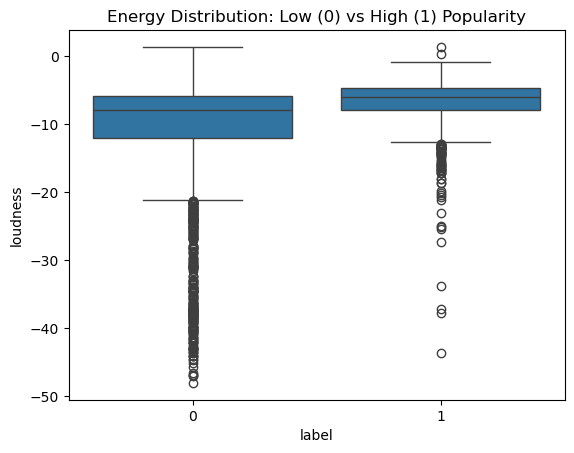

In [ ]:
sns.boxplot(data=df, x='label', y='loudness')
plt.title("Energy Distribution: Low (0) vs High (1) Popularity")
plt.show()

This box plot shows loudness distributions across the two popularity groups. High popularity songs are generally louder, with a higher median and less spread toward the quieter end of the scale. Low popularity songs display a broader range and more outliers on the quieter side, reinforcing the pattern that mainstream popular songs tend to have a more polished, loud production style.

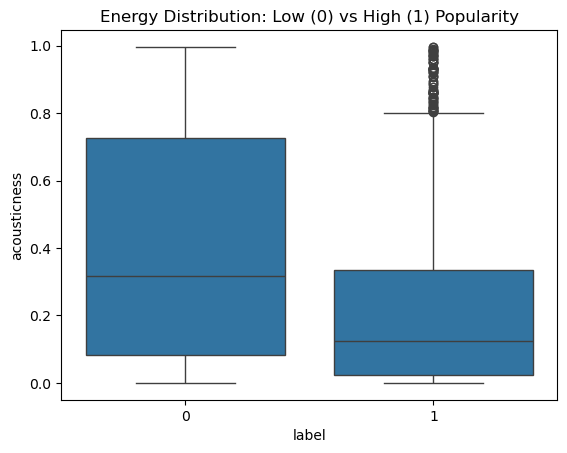

In [ ]:
sns.boxplot(data=df, x='label', y='acousticness')
plt.title("Energy Distribution: Low (0) vs High (1) Popularity")
plt.show()

Acousticness tells perhaps the clearest story of the three box plots. Low popularity songs have a dramatically higher median acousticness and a much wider distribution, while high popularity songs cluster tightly near zero. This confirms that acoustic qualities are strongly associated with lower popularity, likely because heavily produced, non-acoustic sounds dominate mainstream listening.

In [ ]:
key_counts = highPopularity['key'].value_counts().sort_index()
print(key_counts)

mode_counts = highPopularity['mode'].value_counts()
print(mode_counts)

key
0     152
1     227
2     154
3      53
4     123
5     153
6     134
7     151
8     119
9     136
10    112
11    172
Name: count, dtype: int64
mode
1    975
0    711
Name: count, dtype: int64


Finally, I analyzed the distribution of musical key and mode. The key variable, which is encoded as values from 0 to 11 representing musical pitch classes, was fairly evenly distributed across the dataset, indicating no strong preference for specific keys among popular songs. However, the mode variable showed a noticeable pattern, with a higher number of songs in major mode compared to minor mode in the high popularity dataset. This suggests that songs with a more positive or upbeat tonal structure, typically associated with major keys, may be more likely to achieve higher popularity.

In [ ]:
top_features = comparison.sort_values(by='Difference', ascending=False)
print(top_features[['Difference']])

                    Difference
duration_ms       12921.951441
tempo                 4.304053
loudness              3.959702
energy                0.123707
valence               0.067299
danceability          0.043093
liveness              0.006092
speechiness          -0.001248
acousticness         -0.184347
instrumentalness     -0.245083


In order to determine what makes a song popular, I compared the average values of audio features between the high and low popularity datasets and examined the differences. The largest positive differences were observed in duration, tempo, loudness, energy, valence, and danceability. In particular, loudness (+3.96), tempo (+4.30 BPM), and energy (+0.12) showed notable increases in the high popularity dataset.

These results suggest that popular songs tend to be louder, more energetic, slightly faster, and more rhythmically engaging. Additionally, higher valence values indicate that more popular songs tend to have a more positive or upbeat emotional tone. Danceability also contributes, reinforcing the idea that songs that are easier to move to are more likely to gain popularity.

These findings indicate that popular songs follow a consistent pattern of being high-energy, polished, and engaging, with strong rhythmic and emotional appeal.

In contrast, the largest negative differences were found in instrumentalness (-0.245) and acousticness (-0.184), meaning these features are significantly higher in the low popularity dataset. This indicates that less popular songs are more likely to be instrumental or acoustic in nature.

Additionally, lower values of energy, loudness, and danceability further characterize less popular songs, suggesting that they tend to be quieter, less intense, and less rhythmically engaging. These traits may make them less appealing to a broad audience, particularly in mainstream music environments. Less popular songs appear to deviate from the high-energy and polished sound that defines more popular tracks, instead exhibiting more experimental, acoustic, or niche characteristics.


In [ ]:
genre_pop = lowPopularity.groupby('playlist_genre')['track_popularity'].mean()
print(genre_pop.sort_values(ascending=False))
key_counts = lowPopularity['key'].value_counts().sort_index()
print(key_counts)

mode_counts = lowPopularity['mode'].value_counts()
print(mode_counts)
top_features = comparison.sort_values(by='Difference', ascending=False)
print(top_features[['Difference']])

playlist_genre
korean        59.769231
metal         59.071429
j-pop         58.833333
indie         58.307692
k-pop         56.500000
reggae        55.578947
mandopop      53.785714
punk          52.625000
soul          51.619048
wellness      49.512500
rock          49.118182
hip-hop       49.083333
turkish       49.031250
gospel        47.051282
lofi          46.865320
blues         46.627907
afrobeats     46.290323
jazz          46.213793
electronic    45.875283
folk          45.028571
ambient       45.020134
classical     44.648649
arabic        44.354430
soca          41.857143
gaming        41.363636
latin         41.066390
indian        40.750000
country       40.250000
brazilian     36.238806
funk          32.178571
pop           30.981013
world         28.549107
cantopop      24.592593
disco         24.000000
Name: track_popularity, dtype: float64
key
0.0     357
1.0     360
2.0     307
3.0     109
4.0     238
5.0     255
6.0     252
7.0     325
8.0     199
9.0     294
10.0  

Correlation analysis within the low-popularity dataset shows that relationships between individual features and popularity remain relatively weak, though they are slightly stronger than those observed in the high-popularity dataset. Features such as danceability and speechiness exhibit small positive correlations, suggesting that songs with stronger rhythm and more vocal presence may have a slightly better chance of gaining popularity within this lower range. Despite this, most features still display minimal correlation, indicating that no single audio characteristic strongly determines popularity on its own. Compared to the high-popularity dataset, where correlations are nearly negligible, this suggests that audio features play a somewhat larger role among less popular songs, though their overall influence remains limited.

Examining genre within the low-popularity dataset reveals greater variation in average popularity scores than in the high-popularity group. Genres such as Korean, metal, and J-pop have the highest average popularity within this subset, while disco, cantopop, and world music rank significantly lower. Interestingly, genres like pop, which perform well in the high-popularity dataset, show relatively low average popularity in the low-popularity group. This indicates that while genre can influence popularity, its effect is inconsistent across different popularity levels. Instead, genre likely interacts with other factors, such as audio features and audience reach, making it an unreliable predictor of success on its own.

The distribution of musical key in the low-popularity dataset is relatively even, mirroring the pattern seen in the high-popularity dataset. No single key dominates, reinforcing the idea that pitch class alone has little influence on popularity. Mode distribution, however, shows a consistent pattern, with songs in major mode outnumbering those in minor mode. Although this trend appears in both datasets, it is slightly less pronounced among less popular songs. This suggests that while major mode may contribute to a more appealing or positive sound, it is not sufficient by itself to drive popularity.

Comparing the high- and low-popularity datasets reveals several consistent trends. More popular songs tend to be louder, more energetic, faster-paced, and more danceable, while less popular songs are more likely to be acoustic and instrumental. These differences are reflected in the strong negative gaps in instrumentalness and acousticness, alongside positive differences in loudness, tempo, and energy. Additionally, genre appears to have a more variable influence in the low-popularity dataset, further emphasizing its limited reliability as a predictor of success. Key remains largely irrelevant across both datasets, while mode shows only a slight preference for major tonality among more popular songs. Overall, these findings reinforce the conclusion that popularity is associated with a consistent set of audio characteristics, particularly those related to energy, production, and rhythmic engagement, while less popular songs exhibit greater variability and less alignment with mainstream trends.

### Predictive Modeling

I chose logistic regression because the goal is to classify songs into high or low popularity groups, making this a binary classification problem. The audio features identified in the exploratory analysis are used as input variables to train the model.

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Combine datasets
highPopularity['label'] = 1
lowPopularity['label'] = 0

df = pd.concat([highPopularity, lowPopularity])

features = [
    'energy', 'danceability', 'loudness', 'tempo',
    'valence', 'speechiness', 'instrumentalness',
    'liveness', 'acousticness', 'duration_ms'
]

df = df.dropna(subset=features + ['label'])

# Define X and y AFTER cleaning
X = df[features]
y = df['label']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.6480331262939959
              precision    recall  f1-score   support

           0       0.67      0.86      0.75       604
           1       0.56      0.29      0.38       362

    accuracy                           0.65       966
   macro avg       0.61      0.58      0.57       966
weighted avg       0.63      0.65      0.61       966



To further evaluate whether audio features can predict song popularity, I implemented a logistic regression model to classify songs as either high or low popularity. The model achieved an overall accuracy of approximately 64.8%, indicating that audio features provide some predictive power, but are not sufficient on their own to fully explain popularity.

A closer look at the classification metrics reveals an imbalance in performance between the two classes. The model performed significantly better at identifying low popularity songs, achieving a recall of 0.86, meaning it correctly identified most less popular tracks. However, its performance on high popularity songs was weaker, with a recall of only 0.29, indicating that many popular songs were incorrectly classified as low popularity.

This discrepancy suggests that while less popular songs tend to follow more consistent and distinguishable patterns (such as higher acousticness and instrumentalness), popular songs are more difficult to predict. This aligns with earlier findings, where feature correlations within the high popularity dataset were weak, implying that factors beyond audio characteristics, such as artist reputation, marketing, and cultural trends, may play a larger role in determining high popularity.

Overall, the model supports the conclusion that audio features can partially explain song popularity, particularly for identifying less popular songs, but they are not sufficient to fully predict which songs will become highly popular.

In this project, I analyzed how audio features relate to song popularity using both exploratory analysis and a classification model. My findings show that popular songs tend to be more energetic, louder, faster, and more danceable, while less popular songs are more likely to be acoustic and instrumental.

However, correlation analysis and modeling results suggest that audio features alone are not strong predictors of high popularity. The logistic regression model achieved moderate accuracy but struggled to correctly identify highly popular songs, indicating that external factors such as marketing, artist popularity, and cultural trends likely play a significant role.

Overall, while audio features help distinguish less popular songs, they are not sufficient to fully explain what makes a song highly popular.